This file is meant to test changes to the noisy gates library downloaded in this folder offline

get API key here: ```https://cloud.ibm.com/iam/apikeys```



### Preparation

In [1]:
import os
os.chdir("/Users/cherie/Desktop/quantum-gates/src")  # or any folder that actually exists
print(os.getcwd())

/Users/cherie/Desktop/quantum-gates/src


In [2]:
# Standard libraries
import numpy as np
import json
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

# Qiskit
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.controlflow import ControlFlowOp
from qiskit.result import marginal_counts
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeBrisbane


# Own library
from quantum_gates.utilities import fix_counts
from quantum_gates.simulators import MrAndersonSimulator
from quantum_gates.circuits import EfficientCircuit, BinaryCircuit
from quantum_gates.utilities import SurfaceCode
from quantum_gates.utilities import RotatedSurfaceCode

    

# -------------------------------
# Create and load the fake backend
# -------------------------------

# Pick a fake backend
backend = FakeBrisbane()  # 127 qubits; change to another Fake*V2 if import fails


#### Helper Function

In [5]:
def check_syndrome_repetition_on_spaced_key(spaced_key: str) -> bool:
    """
    Checks if the syndrome cycles (all parts after the first one) are identical.
    
    Args:
        spaced_key (str): The measurement outcome string with spaces 
                          (e.g., '111000111 00001010 00001010').

    Returns:
        bool: True if all syndrome cycles are identical, False otherwise.
    """
    # 1. Split the key by spaces
    registers = spaced_key.split(' ')
    
    # 2. Check if there are any syndrome cycles to compare (must have at least 2 registers total)
    if len(registers) <= 2:
        # 1st register is data, 2nd is the first syndrome cycle. Cannot check for repetition yet.
        return True 

    # 3. The first syndrome cycle is the second element in the list (index 1)
    first_syndrome = registers[1]
    
    # 4. Compare the first syndrome against all subsequent cycles (index 2 onwards)
    for i in range(2, len(registers)):
        next_syndrome = registers[i]
        
        # Check for non-repetition
        if next_syndrome != first_syndrome:
            return False # Found a non-repeating cycle
            
    # If the loop completes, all syndrome cycles were identical
    return True

### Create Circuit

#### Planar Surface Code

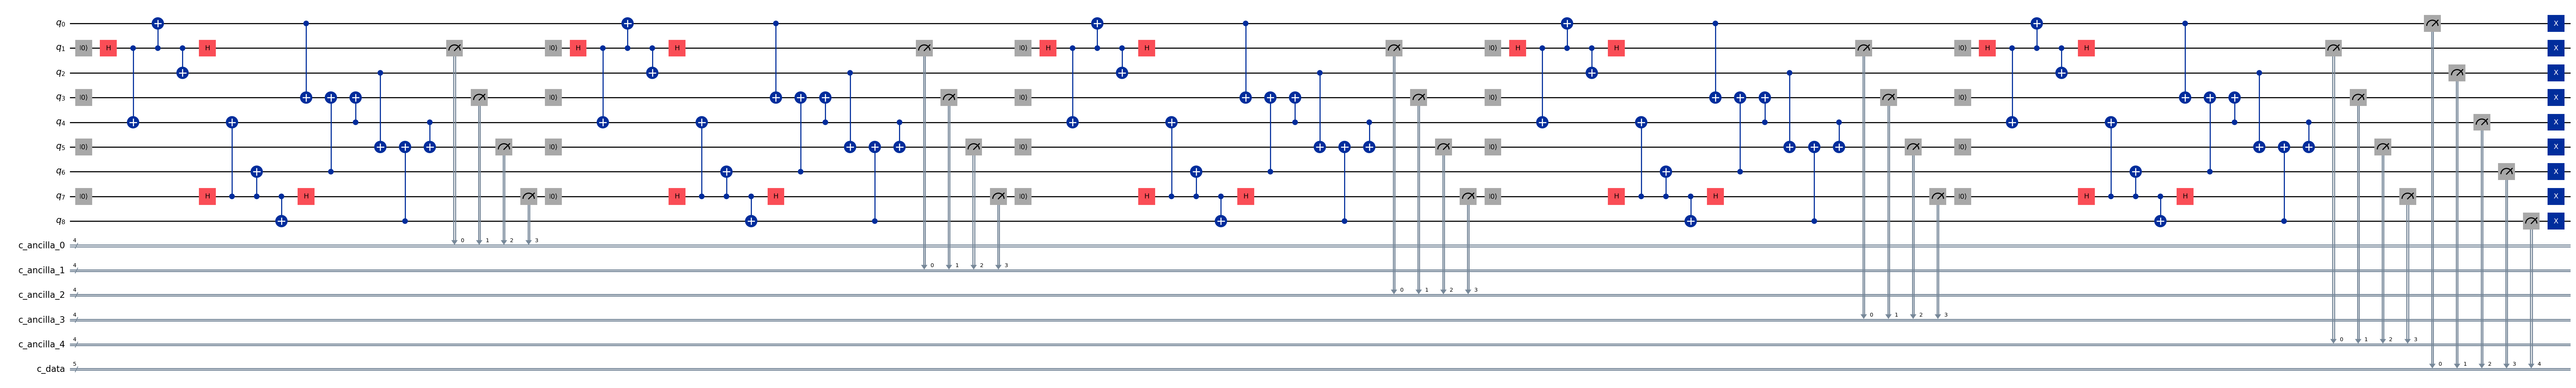

In [7]:
shots = 1
cycles = 5
distance = 2
code = SurfaceCode(distance=distance, cycles=cycles)
code.qc.draw("mpl", fold=False, plot_barriers=False)

In [ ]:
processed_counts, t_circ = code.run_surfacecode(noise = True, shots=shots)
print("Mid-circuit measurement counts:", processed_counts)

In [ ]:
plot_histogram(processed_counts)

In [ ]:
syndrome_repetition_summary = {}

print("Checking syndrome repetition across cycles...")
print("-" * 40)

for spaced_key, count in processed_counts.items():
    is_repeating = check_syndrome_repetition_on_spaced_key(spaced_key)
    
    # Store the result alongside the count
    syndrome_repetition_summary[spaced_key] = {
        "count": count,
        "repeating_syndrome": is_repeating
    }
    
    # Print the status for easy debugging
    status = "REPEATING" if is_repeating else "NOT REPEATING"
    print(f"Key: {spaced_key} | Count: {count} | Status: {status}")

#### Rotated Surface Code

Stabilizers: [(2, 4), (2, 6), (4, 10), (4, 12), (0, 0), (2, 5), (4, 11), (6, 16)]
Data qubits: [1, 2, 3, 7, 8, 9, 13, 14, 15]
X stabilizers: [(2, 4), (2, 6), (4, 10), (4, 12)]
Z stabilizers: [(0, 0), (2, 5), (4, 11), (6, 16)]
n_qubits = 17
[[1 0 0 1 0 0 0 0 0]
 [0 1 1 0 1 1 0 0 0]
 [0 0 0 1 1 0 1 1 0]
 [0 0 0 0 0 1 0 0 1]]
[[0 1 1 0 0 0 0 0 0]
 [1 1 0 1 1 0 0 0 0]
 [0 0 0 0 1 1 0 1 1]
 [0 0 0 0 0 0 1 1 0]]
Decoder setup complete.


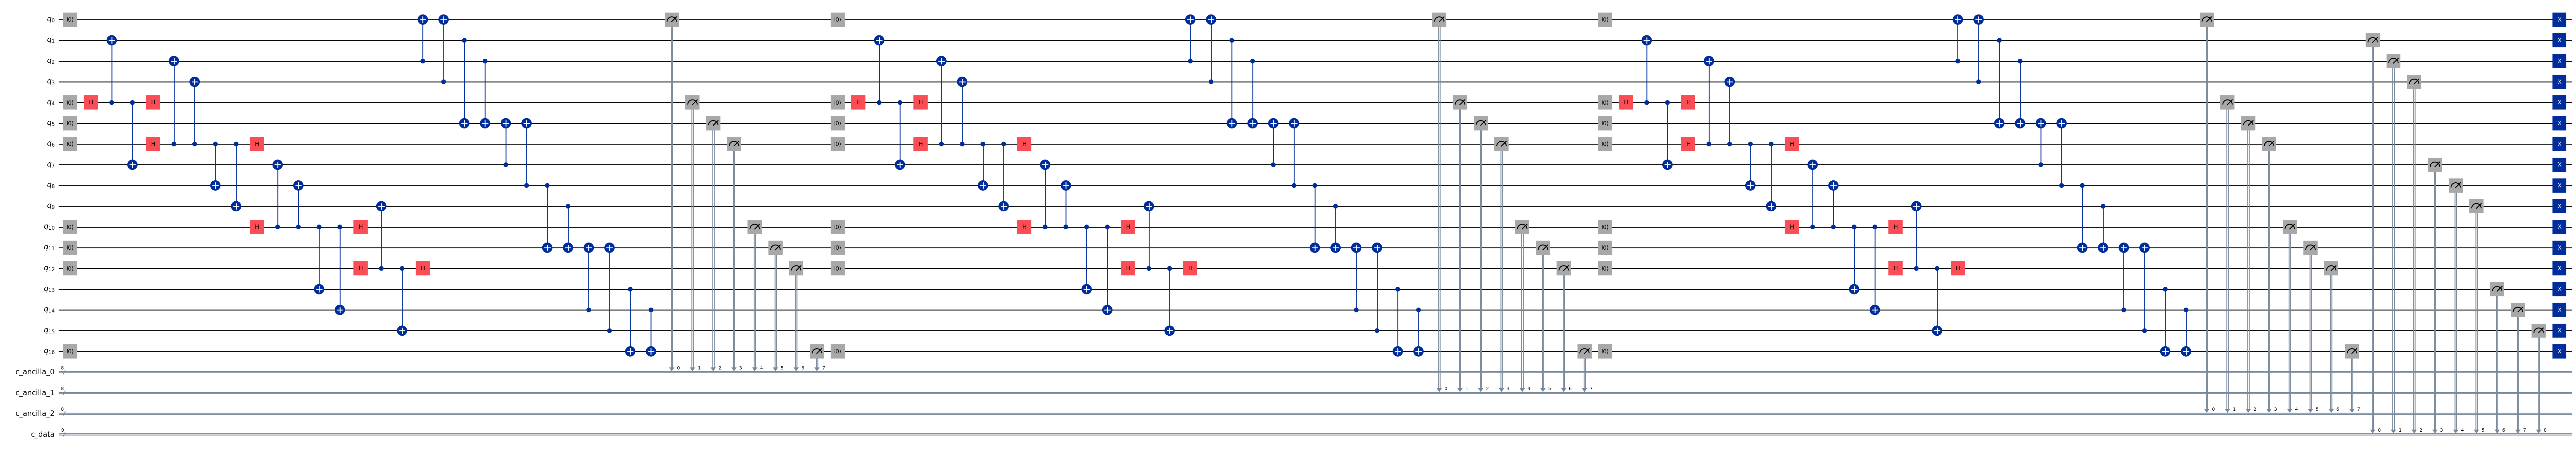

In [8]:
shots = 1
cycles = 3
distance = 3
code = RotatedSurfaceCode(distance=distance, cycles=cycles)
#qc = code.qc
#qc.x(range(0,code.n_qubits))  # introduce bit-flip errors on all data qubits
code.qc.draw("mpl", fold=False, plot_barriers=False)

In [13]:
processed_counts, t_circ = code.run_surfacecode(noise = True, shots=shots)
print("Mid-circuit measurement counts:", processed_counts)


Qubits used in transpiled circuit: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Using average p_int: 0.010364728578052478
Set p_int for edge (0,1): 0.010364728578052478
Set p_int for edge (1,2): 0.010364728578052478
Set p_int for edge (2,3): 0.010364728578052478
Set p_int for edge (3,4): 0.010364728578052478
Set p_int for edge (5,6): 0.005666572877217058
Set p_int for edge (9,10): 0.008216179511250532
Set p_int for edge (12,13): 0.004073877156212158
Set p_int for edge (13,14): 0.004073877156212158
Set p_int for edge (14,15): 0.004073877156212158
Set p_int for edge (15,16): 0.004073877156212158
Device parameters loaded for qubits: {'T1': [0.00023736364020705798, 0.00015845256790461264, 0.000225591023977547, 0.0003936306508437054, 0.00017646159413810941, 0.00025814772575150557, 0.0002968972491552427, 0.00014469334922889853, 0.00027097320521285873, 0.00041528680075195764, 0.0004041542397937308, 0.0002057224190331731, 0.0004007949909070647, 0.00031937029340210906, 0.000249934

In [ ]:
t_circ.draw("mpl")

In [ ]:
plot_histogram(processed_counts, title="Rotated Surface Code Mid-Circuit Measurement Counts on Mr Anderson Simulator")

In [6]:
syndrome_repetition_summary = {}

print("Checking syndrome repetition across cycles...")
print("-" * 40)

for spaced_key, count in processed_counts.items():
    is_repeating = check_syndrome_repetition_on_spaced_key(spaced_key)
    
    # Store the result alongside the count
    syndrome_repetition_summary[spaced_key] = {
        "count": count,
        "repeating_syndrome": is_repeating
    }
    
    # Print the status for easy debugging
    status = "REPEATING" if is_repeating else "NOT REPEATING"
    print(f"Key: {spaced_key} | Count: {count} | Status: {status}")

Checking syndrome repetition across cycles...
----------------------------------------
Key: 000001001 00010010 00010010 00010010 | Count: 1 | Status: REPEATING
Key: 011010001 01010010 01010010 01010010 | Count: 1 | Status: REPEATING
Key: 000110110 00010010 00010010 00010010 | Count: 1 | Status: REPEATING
Key: 111111000 01011010 01011010 01011010 | Count: 1 | Status: REPEATING
Key: 100100000 00011010 00011010 00011010 | Count: 1 | Status: REPEATING


### AER Simulation

In [8]:
# Simulate with Aer
shots = 260
sim = AerSimulator()
result = sim.run( t_circ, shots=shots).result()
aer_counts = result.get_counts()
print("Aer Simulator counts:", aer_counts)

In [ ]:
plot_histogram(aer_counts, title="Aer Simulator")